In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Titanic

In [358]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [359]:
df = pd.read_csv('/content/drive/MyDrive/Data Science/Machine Learning /Machine test/Titanic-Dataset.csv')

In [360]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [361]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [363]:
df.shape

(891, 12)

In [364]:
columns =df.columns
print(columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [365]:
columns_to_drop = ['PassengerId', 'Pclass', 'Name', 'SibSp']
df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   Parch     891 non-null    int64  
 4   Ticket    891 non-null    object 
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 55.8+ KB


In [367]:
from sklearn.preprocessing import LabelEncoder

In [368]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    label=le.fit(df[column])
    df[column] = label.fit_transform(df[column])

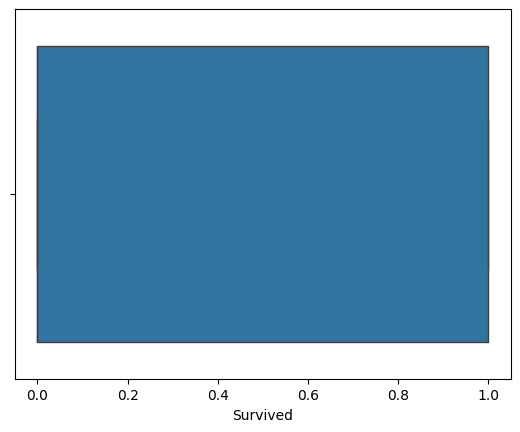

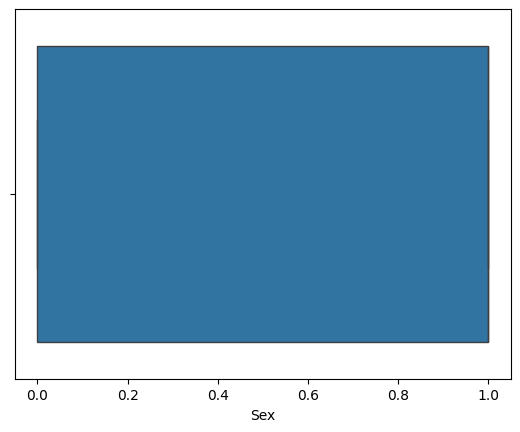

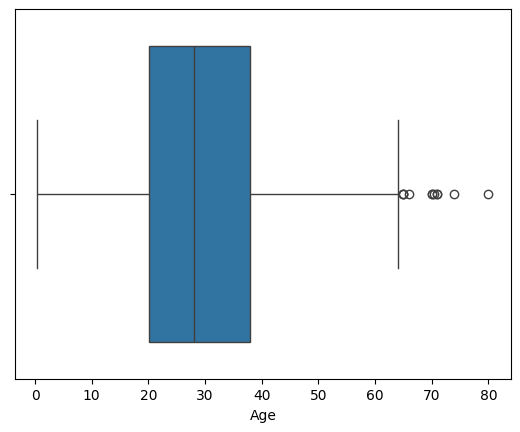

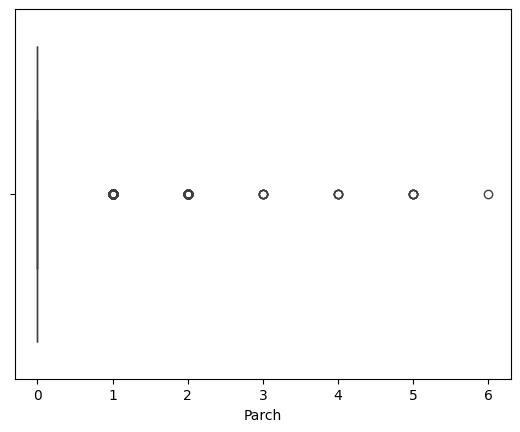

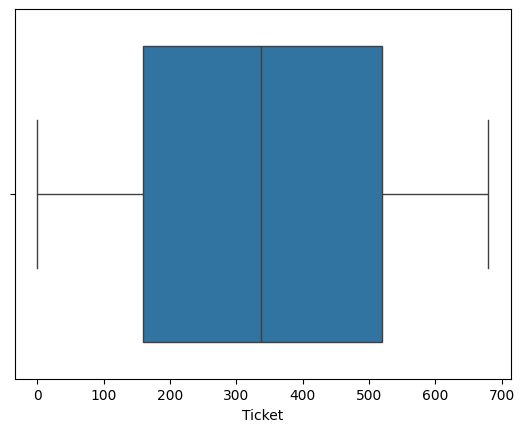

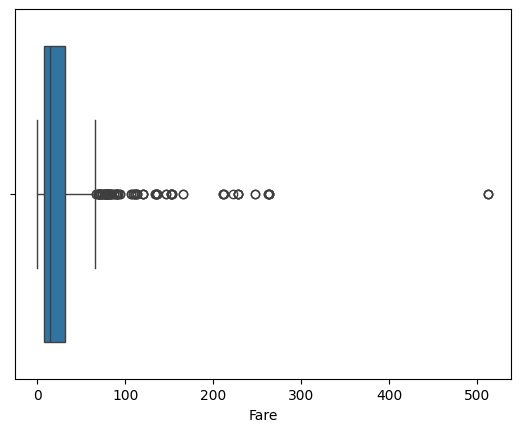

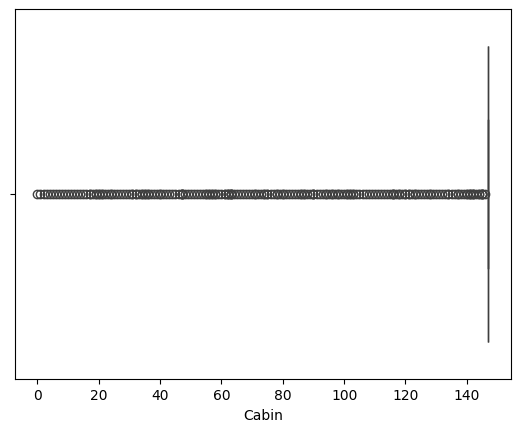

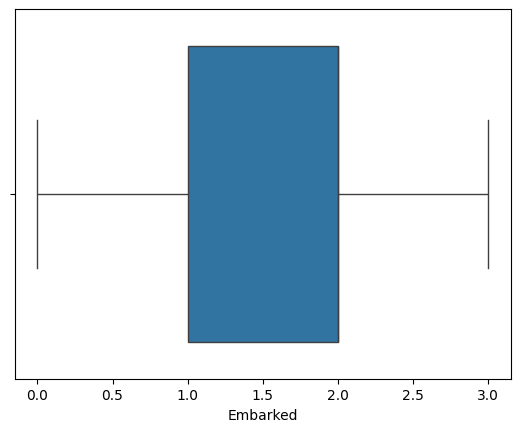

In [369]:
for column in df.columns:
    sns.boxplot(x=df[column])
    plt.show()

In [370]:
def remove_outliers(df, column, multiplier=1.5): #has alot
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Before removal
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(df[column])
    plt.title(f'{column} Before Outlier Removal')

    # Filter out the outliers
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    # After removal
    plt.subplot(1, 2, 2)
    sns.boxplot(df_cleaned[column])
    plt.title(f'{column} After Outlier Removal')

    plt.show()

    return df_cleaned

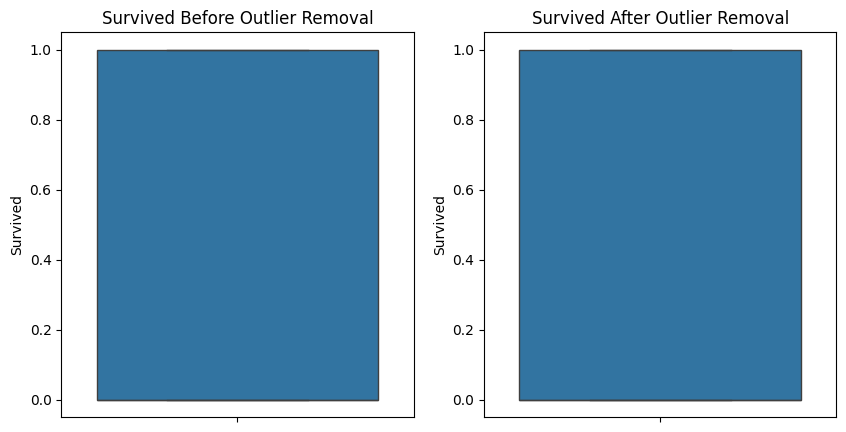

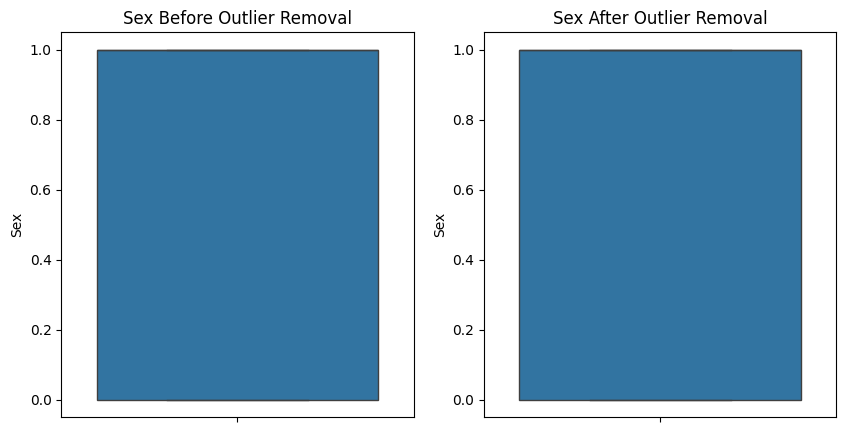

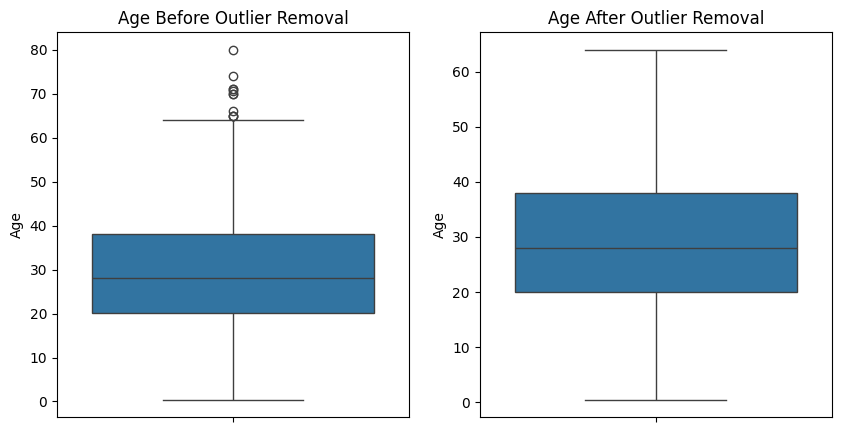

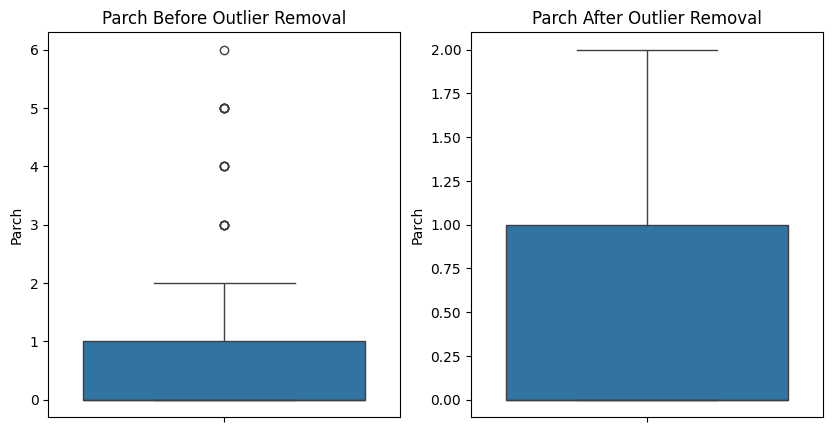

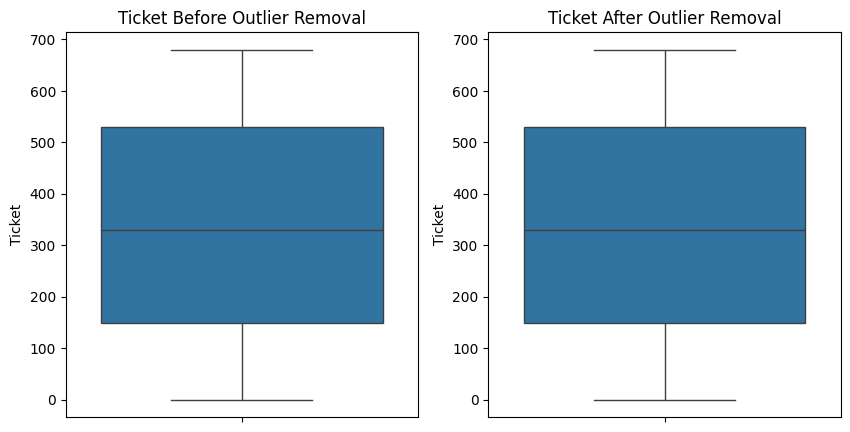

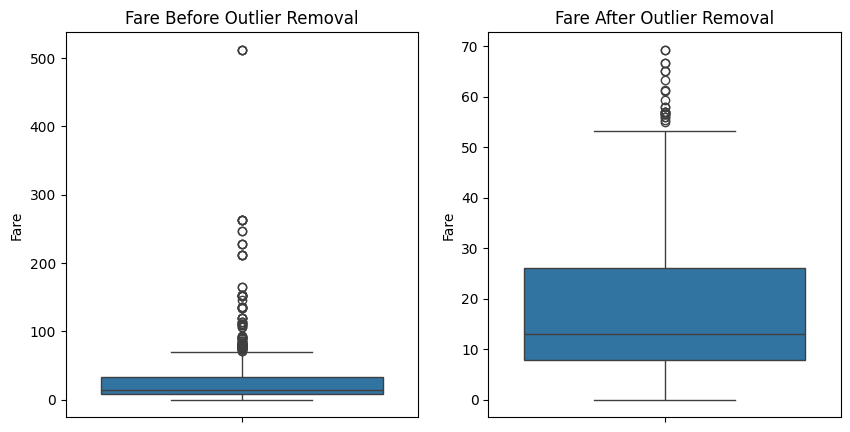

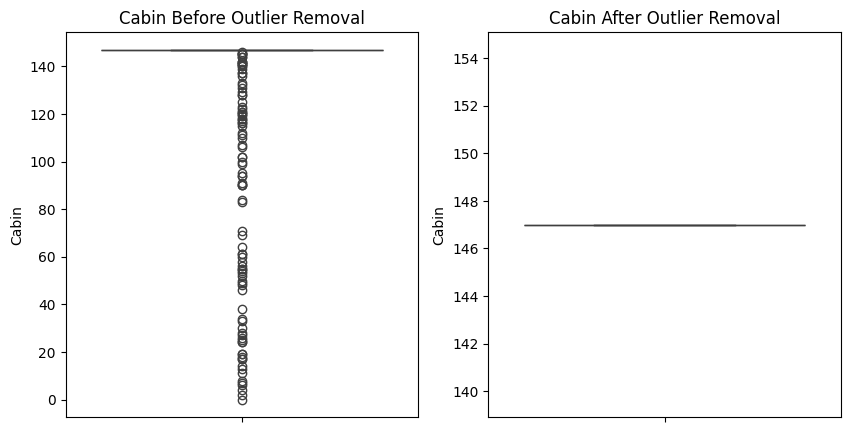

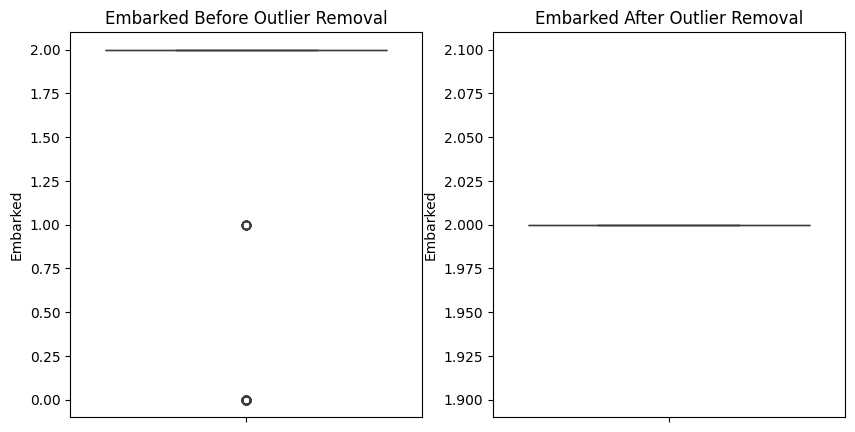

In [371]:
num = df.select_dtypes(include=['number']).columns

for col in num:
    df = remove_outliers(df, col)

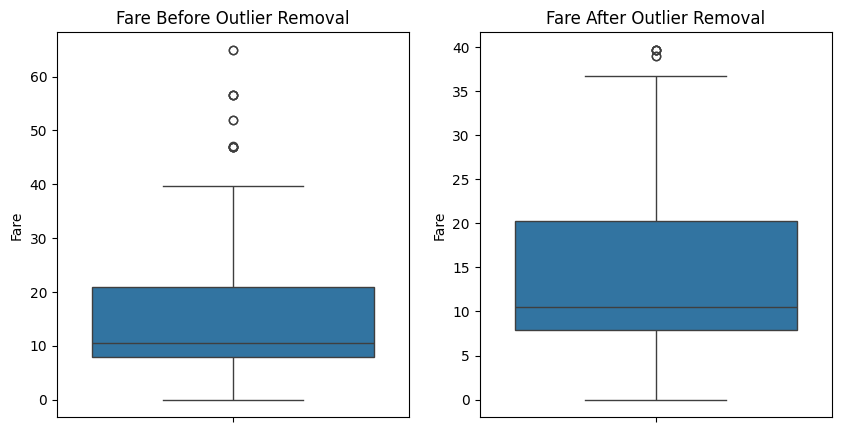

In [372]:
df = remove_outliers(df, "Fare", multiplier=2.5)

In [373]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 886
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  400 non-null    int64  
 1   Sex       400 non-null    int64  
 2   Age       400 non-null    float64
 3   Parch     400 non-null    int64  
 4   Ticket    400 non-null    int64  
 5   Fare      400 non-null    float64
 6   Cabin     400 non-null    int64  
 7   Embarked  400 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 28.1 KB


In [374]:
df.isna().any()

,0
Survived,False
Sex,False
Age,False
Parch,False
Ticket,False
Fare,False
Cabin,False
Embarked,False


In [375]:
df.isna().sum()

,0
Survived,0
Sex,0
Age,0
Parch,0
Ticket,0
Fare,0
Cabin,0
Embarked,0


In [377]:
for i in df.columns:
  print(df[i].unique(),i)
  print('\n')

[0 1] Survived


[1 0] Sex


[22.   26.   35.    2.   27.   20.   14.   55.   31.    8.   21.   18.
 40.    7.   29.    5.    4.   19.   17.   32.    0.83 30.   33.   24.
 59.   34.   28.   37.   38.   45.   47.   25.   16.    9.   42.   51.
 55.5  40.5  44.    1.   36.   20.5  54.   41.   50.    3.   43.   61.
 23.   46.   39.   10.   13.   48.   56.   63.   11.   64.   62.   49.
 24.5  60.   52.    6.   28.5   0.67 30.5 ] Age


[0 1 2] Parch


[523 669 472 395 344 535 413 153 301 139 514 302 507  53 377 249 522 239
 555 561 337 623 248 270 557 158 432 304 311 637 247 297 298 341 548 428
 117 150 384 505 245 354 296 388 274 491 666 333 541 318 640 537 111 552
 504 332 668 118 558 405 676 147 622 516 538 654 470 559 323 265 423 659
 412 169 574 329 271  11 386 122 227 406 494 160 306 242 530 642 570 526
 163 670 142 679 653 105 102 615 672 525 125 322 128 554 198 556 231 636
 674 658 325 166 144 536 458 115 546 334 162 326 551 340 310 533 308 353
 134 376 374 167 382 571 343 232 524 36

In [378]:
df.duplicated().sum()

0

In [379]:
x = df.drop('Survived', axis=1)
y = df['Survived']

In [380]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [381]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Decision tree

In [382]:
from sklearn.tree import DecisionTreeClassifier

In [383]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train = std.fit_transform(x_train)
x_test = std.transform(x_test)

In [384]:
df['Survived'].value_counts()

,count
Survived,
0,286
1,114


In [385]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [386]:
dt_pred=dt.predict(x_test)
dt_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [387]:
y_train.value_counts()

,count
Survived,
0,220
1,100


In [388]:
print(y_test.value_counts())

Survived
0    66
1    14
Name: count, dtype: int64


In [389]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,dt_pred)
mse

0.1625

In [390]:
dta = accuracy_score(y_test,dt_pred)
print('accuracy score =',accuracy_score(y_test,dt_pred))

accuracy score = 0.8375


In [391]:
print("Decision Tree Classification Report:")
print(classification_report(y_test,dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        66
           1       0.53      0.57      0.55        14

    accuracy                           0.84        80
   macro avg       0.72      0.73      0.73        80
weighted avg       0.84      0.84      0.84        80



In [392]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,dt_pred))

Confusion Matrix:
[[59  7]
 [ 6  8]]


Smote

In [393]:
from imblearn.over_sampling import SMOTE

In [394]:
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x_train, y_train)

In [395]:
y_res.value_counts()

,count
Survived,
0,220
1,220


In [396]:
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(x_res, y_res)

DecisionTreeClassifier(random_state=42)

In [397]:
x_res=std.fit_transform(x_res)

In [398]:
dt_pred1=dt1.predict(x_test)
dt_pred1

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [399]:
print("Decision Tree Classification Report:")
print(classification_report(y_test,dt_pred1))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91        66
           1       0.58      0.79      0.67        14

    accuracy                           0.86        80
   macro avg       0.76      0.83      0.79        80
weighted avg       0.89      0.86      0.87        80



In [400]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,dt_pred1))

Confusion Matrix:
[[58  8]
 [ 3 11]]


In [401]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,dt_pred1)
mse

0.1375

In [402]:
training_score=dt.score(x_train,y_train)
training_score

1.0

In [403]:
testing_score=dt.score(x_test,y_test)
testing_score

0.8375

In [404]:
dtas = accuracy_score(y_test,dt_pred1)
print('accuracy score =',accuracy_score(y_test,dt_pred1))

accuracy score = 0.8625


#KNN

In [405]:
df.size

3200

In [406]:
df.shape

(400, 8)

In [407]:
corln=df.corr()
corln

,Survived,Sex,Age,Parch,Ticket,Fare,Cabin,Embarked
Survived,1.000000,-0.519288,-0.114418,0.225408,-0.053067,0.187620,NaN,NaN
Sex,-0.519288,1.000000,0.120051,-0.306437,0.080096,-0.270713,NaN,NaN
Age,-0.114418,0.120051,1.000000,-0.398750,-0.064543,-0.145684,NaN,NaN
Parch,0.225408,-0.306437,-0.398750,1.000000,-0.013169,0.602758,NaN,NaN
Ticket,-0.053067,0.080096,-0.064543,-0.013169,1.000000,-0.287097,NaN,NaN
Fare,0.187620,-0.270713,-0.145684,0.602758,-0.287097,1.000000,NaN,NaN
Cabin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Embarked,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [408]:
corrln = df.corr()['Survived']
print(corrln)

Survived    1.000000
Sex        -0.519288
Age        -0.114418
Parch       0.225408
Ticket     -0.053067
Fare        0.187620
Cabin            NaN
Embarked         NaN
Name: Survived, dtype: float64


In [409]:
from sklearn.neighbors import KNeighborsClassifier

In [410]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [411]:
knn_pred = knn.predict(x_test)

In [412]:
knn_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [413]:
print(y_train.value_counts())

Survived
0    220
1    100
Name: count, dtype: int64


In [414]:
print(y_test.value_counts())

Survived
0    66
1    14
Name: count, dtype: int64


In [415]:
kna = accuracy_score(y_test,knn_pred)
print('acuracy score =',accuracy_score(y_test,knn_pred))

acuracy score = 0.8375


In [416]:
print("k-NN Classification Report:")
print(classification_report(y_test, knn_pred))

k-NN Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        66
           1       0.53      0.64      0.58        14

    accuracy                           0.84        80
   macro avg       0.73      0.76      0.74        80
weighted avg       0.85      0.84      0.84        80



In [417]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

Confusion Matrix:
[[58  8]
 [ 5  9]]


In [418]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,knn_pred)
mse

0.1625

In [419]:
training_score=knn.score(x_train,y_train)
training_score

0.821875

In [420]:
testing_score=knn.score(x_test,y_test)
testing_score

0.8375

Grid search

In [421]:
from sklearn.model_selection import GridSearchCV

In [422]:
params={'n_neighbors':[3,5,7,9,11],'weights':['uniform','distance']}
clf=GridSearchCV(knn,params,cv=10,scoring='accuracy')
clf.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [423]:
clf.best_params_

{'n_neighbors': 9, 'weights': 'distance'}

In [424]:
clf2=KNeighborsClassifier(n_neighbors=9,weights='distance')
clf2.fit(x_train,y_train)
clf_pred=clf2.predict(x_test)

In [425]:
accuracy_score(y_test,clf_pred)

0.8625

In [441]:
training_score=clf.score(x_train,y_train)
training_score

1.0

In [442]:
testing_score=clf.score(x_test,y_test)
testing_score

0.8625

In [426]:
df.head()

,Survived,Sex,Age,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,22.0,0,523,7.2500,147,2
2,1,0,26.0,0,669,7.9250,147,2
4,0,1,35.0,0,472,8.0500,147,2
7,0,1,2.0,1,395,21.0750,147,2
8,1,0,27.0,2,344,11.1333,147,2


#Random Forest

In [427]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.ensemble import RandomForestClassifier

In [428]:
from sklearn.model_selection import train_test_split
x_train4,x_test4,y_train4,y_test4=train_test_split(x,y,test_size=0.25,random_state=0)

In [429]:
rf=RandomForestClassifier(n_estimators=50)

In [430]:
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=50)

In [431]:
rf_pred=rf.predict(x_test)

In [432]:
rf_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [433]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,rf_pred)

0.8875

In [434]:
print("Random forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        66
           1       0.67      0.71      0.69        14

    accuracy                           0.89        80
   macro avg       0.80      0.82      0.81        80
weighted avg       0.89      0.89      0.89        80



In [435]:
training_score=rf.score(x_train,y_train)
training_score

1.0

In [436]:
testing_score=rf.score(x_test,y_test)
testing_score

0.8875